In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/weather_cleaned.csv")

In [3]:
df

,T2M,RH2M,PS,datetime
0,7.60,66.63,995.1,2023-01-01 00:00:00
1,7.01,68.41,994.9,2023-01-01 01:00:00
2,6.95,68.69,994.9,2023-01-01 02:00:00
3,6.31,70.77,994.6,2023-01-01 03:00:00
4,6.12,71.02,994.5,2023-01-01 04:00:00
...,...,...,...,...
31843,29.16,85.16,979.3,2026-08-19 19:00:00
31844,28.72,87.20,979.8,2026-08-19 20:00:00
31845,28.35,88.36,980.0,2026-08-19 21:00:00
31846,27.96,89.88,979.8,2026-08-19 22:00:00


## OBSERVATIONS -
* T2M is slightly left skewed, PS is bimodal but now skewed, RH2M is slightly right skewed but we dont need to transform them cause Isolation Forest does not require normally distributed features.
* No significant univariate outliers were observed using boxplot/IQR analysis.
* Temperature exhibits a strong diurnal (24-hour) cycle, with substantial day-to-day variation. Therefore, temporal context should be considered when detecting anomalous temperature readings.
* Surface pressure shows gradual multi-day variation with smaller short-term fluctuations and no obvious anomalous spikes.
* Relative humidity exhibits a strong daily cycle and appears to vary inversely with temperature. Values remain within the physically valid range of 0–100%.
* Temperature and surface pressure show a strong negative correlation (-0.75). Temperature and relative humidity show a weaker negative correlation (-0.32), while relative humidity and pressure have only a very weak negative correlation (-0.14). These relationships may help identify abnormal combinations of sensor readings.
* Temperature shows clear negative relationships with both relative humidity and pressure, with the temperature–pressure relationship being particularly strong. However, these relationships are not perfectly linear. Relative humidity and pressure show no strong visible relationship, consistent with their low correlation (-0.14).
* Temperature shows clear daily and seasonal patterns. It is lowest during early morning hours, rises during the day, and peaks around afternoon. Seasonally, temperature increases from winter toward summer, peaks around June, and then gradually decreases.
* tmospheric pressure shows clear daily and seasonal patterns. Seasonally, pressure tends to decrease as temperature increases, consistent with the strong negative correlation observed between temperature and pressure.
* Relative humidity shows clear daily and seasonal patterns. Humidity is highest during early morning/night and lowest during the afternoon, roughly opposite to temperature. Seasonally, humidity decreases toward April, then rises sharply during the monsoon months, peaking around August, before decreasing again.
* 

## Histogram

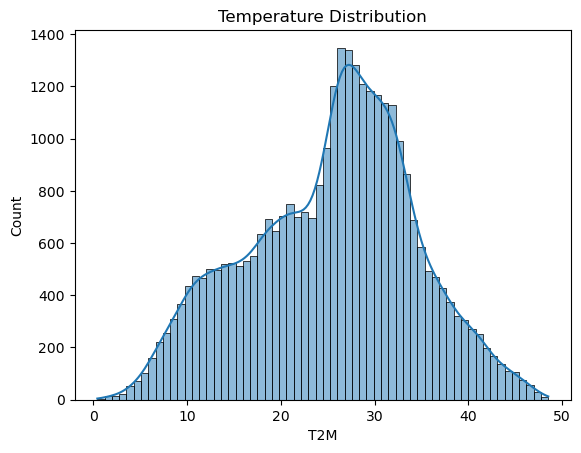

In [4]:
sns.histplot(df['T2M'], kde=True)
plt.title("Temperature Distribution")
plt.show()

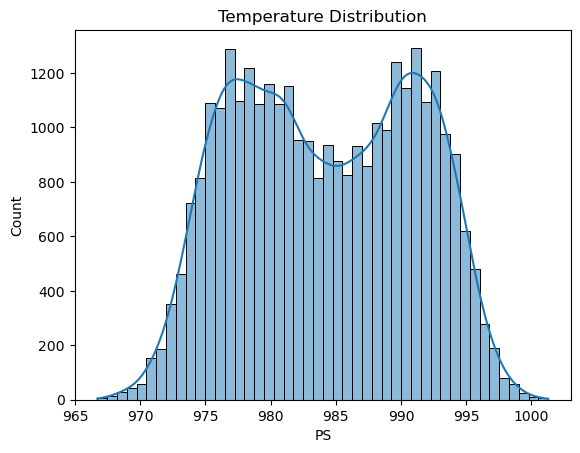

In [5]:
sns.histplot(df['PS'], kde=True)
plt.title("Temperature Distribution")
plt.show()

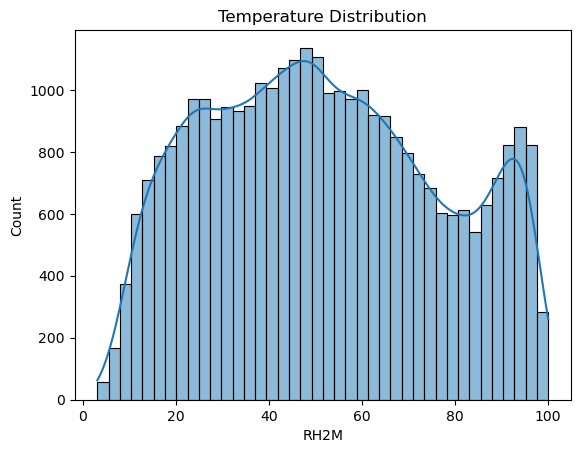

In [6]:
sns.histplot(df['RH2M'], kde=True)
plt.title("Temperature Distribution")
plt.show()

In [7]:
df[['T2M', 'PS', 'RH2M']].skew()

T2M    -0.202698
PS      0.006041
RH2M    0.153775
dtype: float64

## BoxPlots

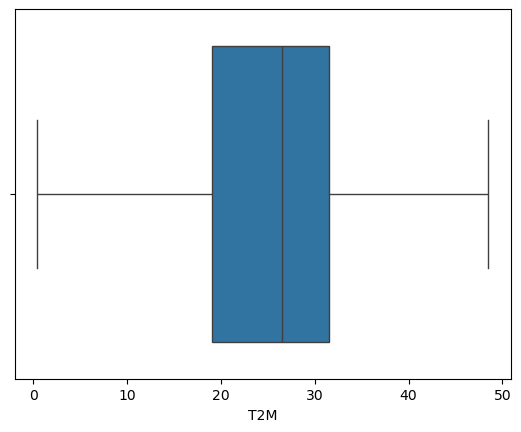

In [8]:
sns.boxplot(x=df['T2M'])
plt.show()

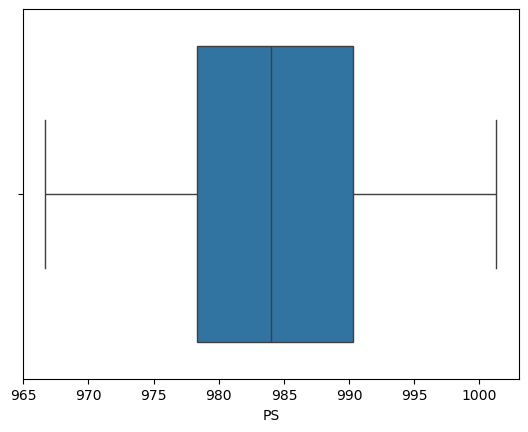

In [9]:
sns.boxplot(x=df['PS'])
plt.show()

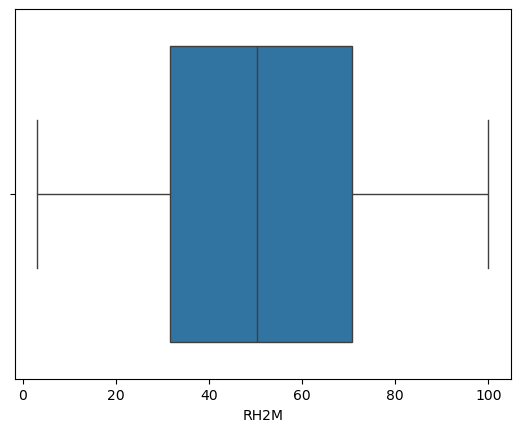

In [10]:
sns.boxplot(x=df['RH2M'])
plt.show()

## TIME-SERIES plot

In [14]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [15]:
df['datetime'].dtype

dtype('<M8[ns]')

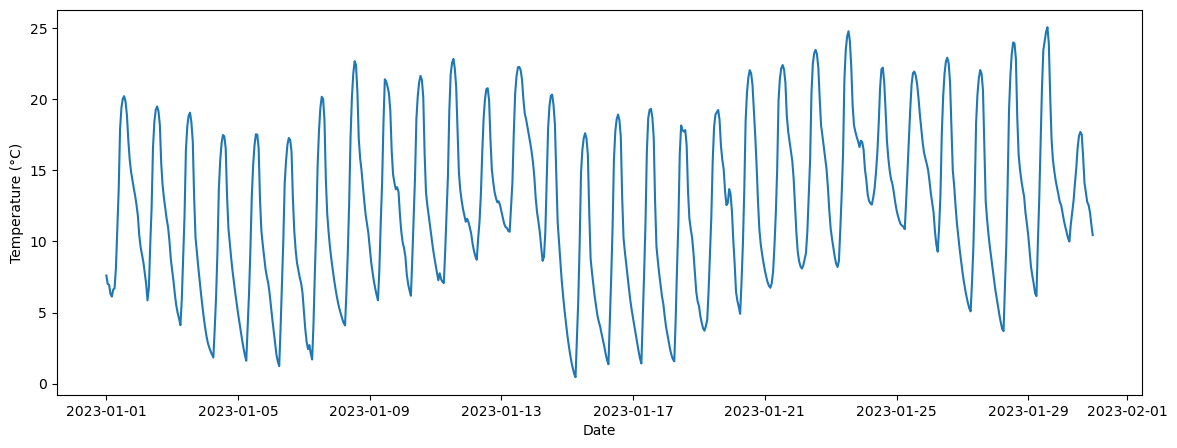

In [16]:
start = df['datetime'].min()
temp = df[df['datetime'] < start + pd.Timedelta(days=30)]

plt.figure(figsize=(14,5))
plt.plot(temp['datetime'], temp['T2M'])
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

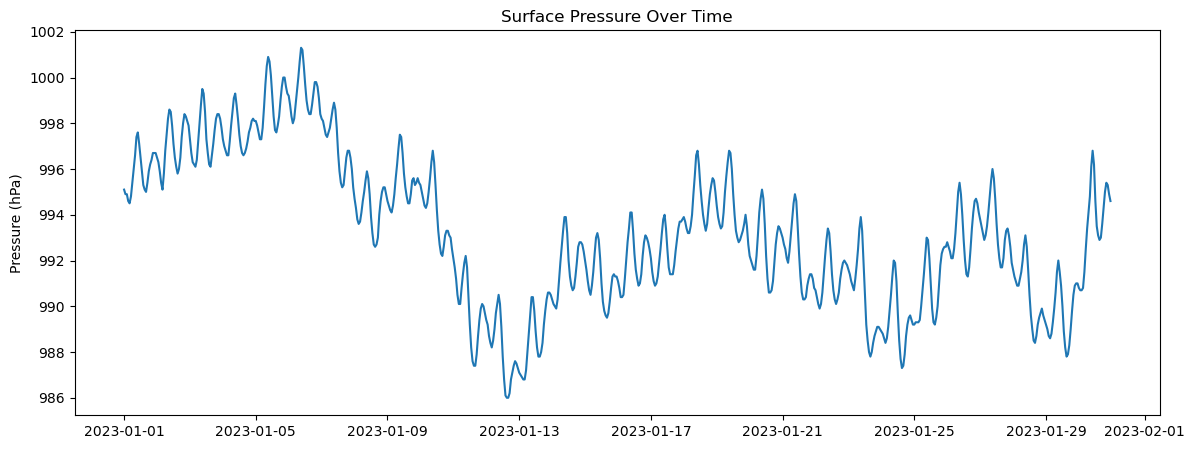

In [19]:
start = df['datetime'].min()
temp = df[df['datetime'] < start + pd.Timedelta(days=30)]

plt.figure(figsize=(14,5))
plt.plot(temp['datetime'], temp['PS'])
plt.ylabel('Pressure (hPa)')
plt.title('Surface Pressure Over Time')
plt.show()

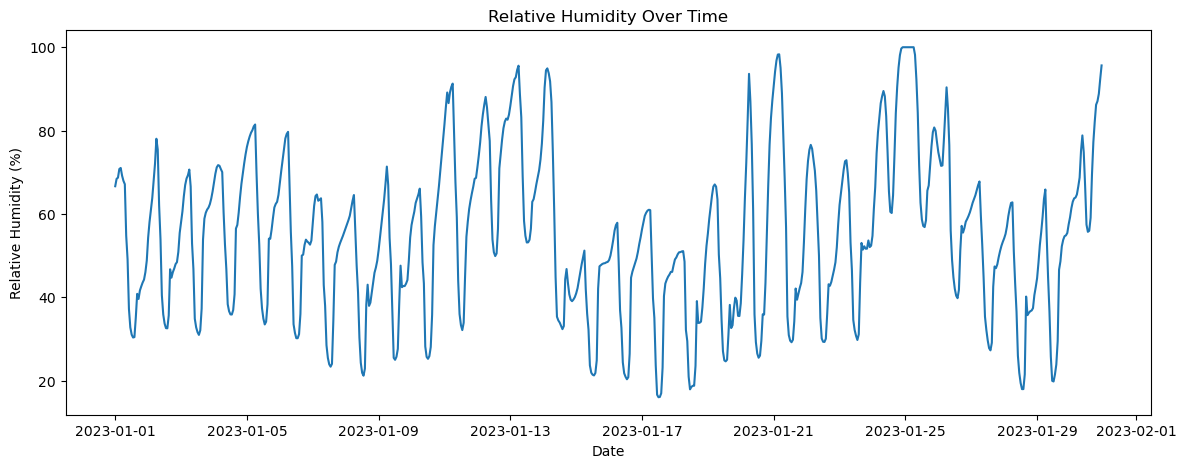

In [21]:
start = df['datetime'].min()
temp = df[df['datetime'] < start + pd.Timedelta(days=30)]

plt.figure(figsize=(14,5))
plt.plot(temp['datetime'], temp['RH2M'])
plt.ylabel('Relative Humidity (%)')
plt.xlabel('Date')
plt.title('Relative Humidity Over Time')
plt.show()

## Relationship between variables

In [22]:
df[['T2M','RH2M','PS']].corr()

,T2M,RH2M,PS
T2M,1.000000,-0.317358,-0.746819
RH2M,-0.317358,1.000000,-0.142896
PS,-0.746819,-0.142896,1.000000


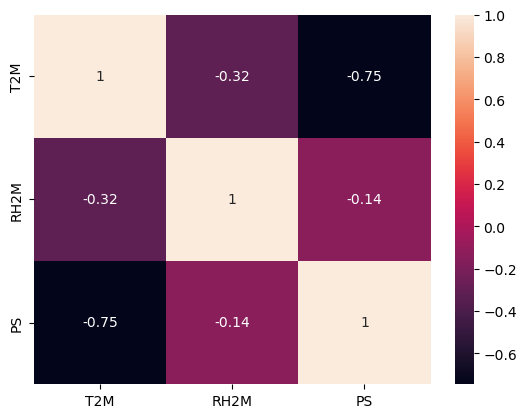

In [23]:
sns.heatmap(
    df[['T2M','RH2M','PS']].corr(),
    annot=True
)
plt.show()

## Scatter Plots

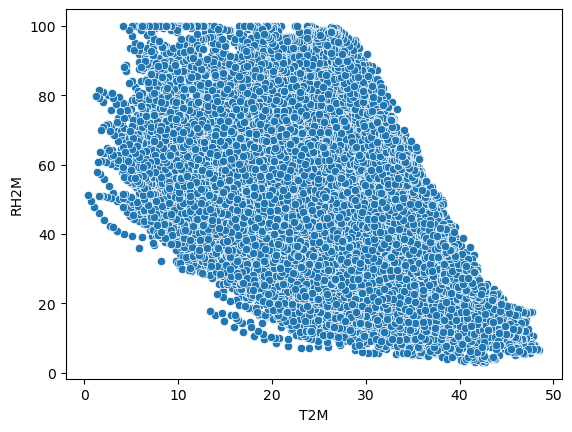

In [24]:
sns.scatterplot(data=df, x='T2M', y='RH2M')
plt.show()

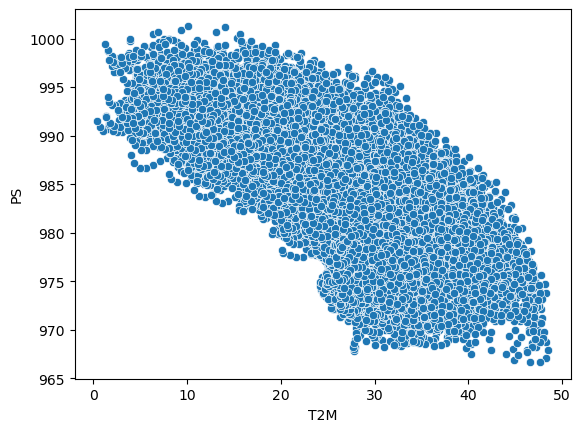

In [25]:
sns.scatterplot(data=df, x='T2M', y='PS')
plt.show()

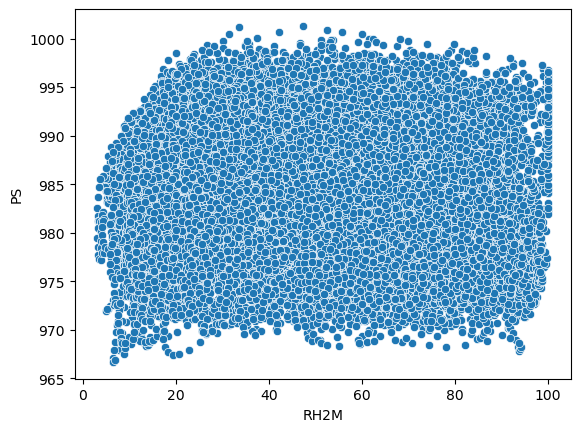

In [27]:
sns.scatterplot(data=df, x='RH2M', y='PS')
plt.show()

## Time Patterns

In [28]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

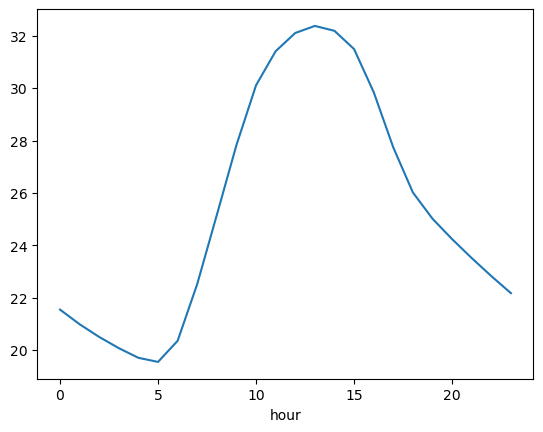

In [30]:
df.groupby('hour')['T2M'].mean().plot()
plt.show()

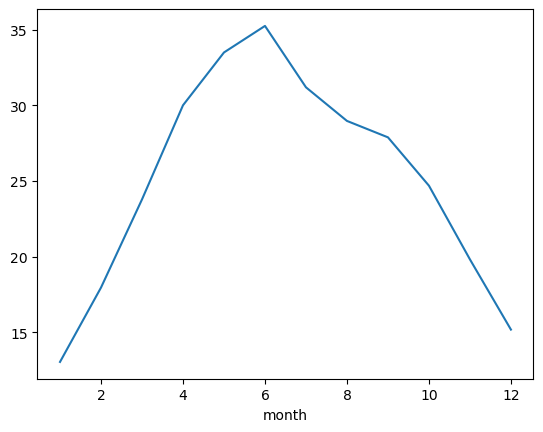

In [31]:
df.groupby('month')['T2M'].mean().plot()
plt.show()

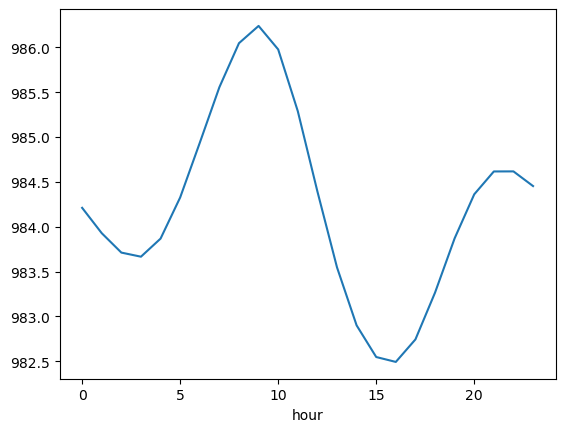

In [32]:
df.groupby('hour')['PS'].mean().plot()
plt.show()

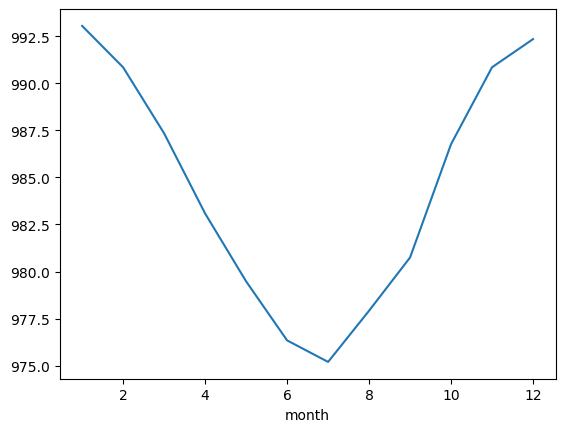

In [33]:
df.groupby('month')['PS'].mean().plot()
plt.show()

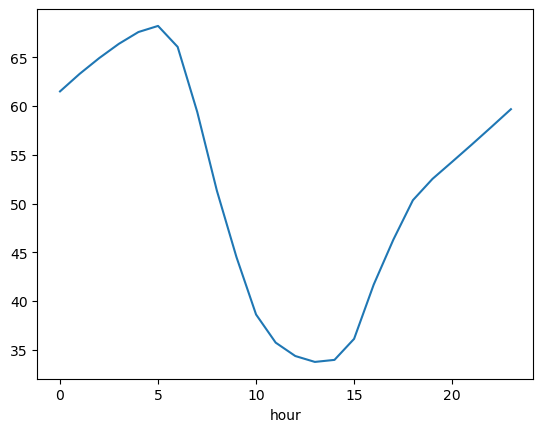

In [34]:
df.groupby('hour')['RH2M'].mean().plot()
plt.show()

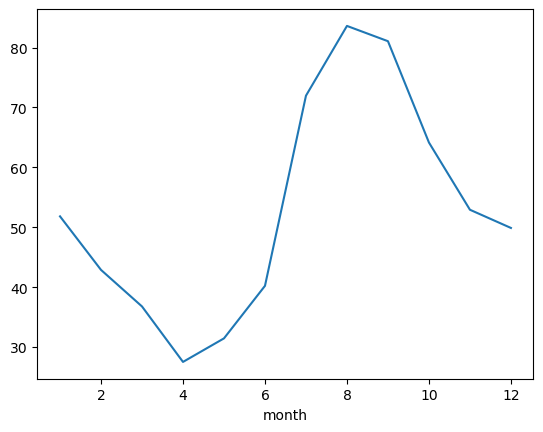

In [35]:
df.groupby('month')['RH2M'].mean().plot()
plt.show()